In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo actual: {device}")

Dispositivo actual: cuda


In [2]:

transform = transforms.Compose([transforms.ToTensor()])

full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# División del conjunto de entrenamiento en Train y Validation ( 80% train, 20% val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Tamaño Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")

100%|██████████| 170M/170M [00:26<00:00, 6.47MB/s] 


Tamaño Train: 40000, Validation: 10000, Test: 10000


In [3]:
def add_gaussian_noise(imgs, sigma=0.1):
    """Agrega una perturbación aleatoria a cada píxel con distribución normal """
    noise = torch.randn_like(imgs) * sigma
    return torch.clamp(imgs + noise, 0., 1.)

def to_grayscale(imgs):
    """Convierte la imagen original RGB a escala de grises (1 canal) """
    grayscale = 0.2989 * imgs[:, 0:1, :, :] + 0.5870 * imgs[:, 1:2, :, :] + 0.1140 * imgs[:, 2:3, :, :]
    return grayscale

def apply_mask(imgs, mask_size=8):
    """Reemplaza una región cuadrada por valores cero """
    masked_imgs = imgs.clone()
    h, w = imgs.shape[2], imgs.shape[3]
    for i in range(imgs.size(0)):
        y = np.random.randint(0, h - mask_size)
        x = np.random.randint(0, w - mask_size)
        masked_imgs[i, :, y:y+mask_size, x:x+mask_size] = 0
    return masked_imgs

def add_salt_and_pepper_noise(imgs, prob=0.1):
    """Agrega ruido sal y pimienta de forma uniforme a todos los canales."""
    noisy = imgs.clone()
    
    batch_size, channels, h, w = imgs.shape
    rnd = torch.rand(batch_size, 1, h, w).to(imgs.device)
    
    rnd = rnd.expand(-1, channels, -1, -1)
    
    # Aplicar "sal" (Blanco puro: 1, 1, 1)
    noisy[rnd < (prob / 2)] = 1.0
    # Aplicar "pimienta" (Negro puro: 0, 0, 0)
    noisy[rnd > 1 - (prob / 2)] = 0.0
    
    return noisy

In [4]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, latent_dim=64): 
        super(ConvAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, latent_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(latent_dim),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.Conv2d(16, out_channels, kernel_size=3, stride=1, padding=1), 
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [ ]:
import torch.nn as nn

class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, latent_dim=64): 
        super(ConvAutoencoder, self).__init__()
        
        # Encoder: (3 -> 32 -> 64 -> 128)
        self.encoder = nn.Sequential(
            # Capa 1: Extrae características iniciales (mantiene tamaño 32x32)
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            # Capa 2: Reduce a 16x16 y aumenta filtros
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            # Capa 3: Reduce a 8x8 y aumenta filtros
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            # Capa 4: Proyección al espacio latente (Cuello de botella)
            nn.Conv2d(128, latent_dim, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(latent_dim),
            nn.ReLU()
        )
        
        # Decoder: Reconstrucción gradual (latent_dim -> 128 -> 64 -> 32 -> out)
        self.decoder = nn.Sequential(
            # Capa 1: Mantiene 8x8 pero procesa el espacio latente
            nn.Conv2d(latent_dim, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            # Capa 2: Sube a 16x16
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            # Capa 3: Sube a 32x32
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            # Capa Final: Ajusta canales y normaliza con Sigmoide
            nn.Conv2d(32, out_channels, kernel_size=3, stride=1, padding=1), 
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [6]:
def train_and_evaluate(model, task_type, train_loader, val_loader, epochs=30, sigma=0.1, mask_size=8, prob=0.1, exp_name=""):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    history = {'epoch': [], 'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        # Fase de Entrenamiento
        model.train()
        train_loss = 0.0
        
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            
            if task_type == 'denoising':
                inputs = add_gaussian_noise(imgs, sigma=sigma).to(device)
                targets = imgs
            elif task_type == 'denoising_sp':
                inputs = add_salt_and_pepper_noise(imgs, prob=prob).to(device)
                targets = imgs
            elif task_type == 'colorization':
                inputs = to_grayscale(imgs).to(device)
                targets = imgs
            elif task_type == 'inpainting':
                inputs = apply_mask(imgs, mask_size=mask_size).to(device)
                targets = imgs

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        train_loss /= len(train_loader)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                
                # --- NUEVA LÓGICA AGREGADA AQUÍ ---
                if task_type == 'denoising':
                    inputs = add_gaussian_noise(imgs, sigma=sigma).to(device)
                    targets = imgs
                elif task_type == 'denoising_sp':
                    inputs = add_salt_and_pepper_noise(imgs, prob=prob).to(device)
                    targets = imgs
                elif task_type == 'colorization':
                    inputs = to_grayscale(imgs).to(device)
                    targets = imgs
                elif task_type == 'inpainting':
                    inputs = apply_mask(imgs, mask_size=mask_size).to(device)
                    targets = imgs

                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                
        val_loss /= len(val_loader)
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'[{exp_name}] Época [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
        
    df = pd.DataFrame(history)
    csv_name = f'historial_{task_type}_{exp_name.replace(" ", "_")}.csv'
    df.to_csv(csv_name, index=False)
    
    return history


def visualize_results(model, task_type, test_loader, indices=[0, 1, 2, 3, 4], sigma=0.1, mask_size=8, prob=0.1, exp_name=""):
    model.eval()
    
    # Extraer las imágenes específicas del dataset original
  
    imgs = torch.stack([test_loader.dataset[i][0] for i in indices]).to(device)
    num_images = len(indices)
    
    # 2. Aplicar la transformación según la tarea
    if task_type == 'denoising':
        inputs = add_gaussian_noise(imgs, sigma=sigma)
    elif task_type == 'denoising_sp':
        inputs = add_salt_and_pepper_noise(imgs, prob=prob)
    elif task_type == 'colorization':
        inputs = to_grayscale(imgs)
    elif task_type == 'inpainting':
        inputs = apply_mask(imgs, mask_size=mask_size)
        
    with torch.no_grad():
        outputs = model(inputs)
        
    imgs, inputs, outputs = imgs.cpu(), inputs.cpu(), outputs.cpu()
    
    fig, axes = plt.subplots(3, num_images, figsize=(num_images * 2.5, 6))
    fig.suptitle(f'Resultados Específicos (Índices: {indices}) - {task_type.capitalize()} | {exp_name}', fontsize=14)
    
    if num_images == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(num_images):
        axes[0, i].imshow(np.transpose(imgs[i].numpy(), (1, 2, 0)))
        axes[0, i].set_title(f"Original (Idx {indices[i]})")
        axes[0, i].axis('off')
        
        if task_type == 'colorization':
            axes[1, i].imshow(inputs[i].squeeze().numpy(), cmap='gray')
        else:
            axes[1, i].imshow(np.transpose(inputs[i].numpy(), (1, 2, 0)))
        axes[1, i].set_title("Entrada")
        axes[1, i].axis('off')
        
        axes[2, i].imshow(np.transpose(outputs[i].numpy(), (1, 2, 0)))
        axes[2, i].set_title("Reconstruida")
        axes[2, i].axis('off')
        
    plt.tight_layout()
    plt.show()

mis_fotos = [10, 81, 99,  184, 322]

In [7]:
def evaluate_on_test(model, task_type, test_loader, sigma=0.1, mask_size=8, prob=0.1, loss_type='mse'):
    """
    Evalúa el modelo entrenado usando únicamente el conjunto de TEST.
    Devuelve la pérdida promedio y el valor de PSNR.
    """
    if loss_type == 'l1':
        criterion = nn.L1Loss()
    else:
        criterion = nn.MSELoss()
        
    model.eval()
    test_loss = 0.0
    
    with torch.no_grad(): 
        for imgs, _ in test_loader:
            imgs = imgs.to(device)
            
            if task_type == 'denoising':
                inputs = add_gaussian_noise(imgs, sigma=sigma).to(device)
                targets = imgs
            elif task_type == 'denoising_sp':
                inputs = add_salt_and_pepper_noise(imgs, prob=prob).to(device)
                targets = imgs
            elif task_type == 'colorization':
                inputs = to_grayscale(imgs).to(device)
                targets = imgs
            elif task_type == 'inpainting':
                inputs = apply_mask(imgs, mask_size=mask_size).to(device)
                targets = imgs

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()
            
    avg_loss = test_loss / len(test_loader)
    
    # Calcular PSNR
    if avg_loss > 0:
        psnr = 10 * math.log10(1.0 / avg_loss)
    else:
        psnr = float('inf')
        
    return avg_loss, psnr

In [8]:
def plot_loss_curves(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history['epoch'], history['train_loss'], label='Train Loss', color='blue', marker='o')
    plt.plot(history['epoch'], history['val_loss'], label='Val Loss', color='red', marker='x')
    
    plt.title(title)
    plt.xlabel('Época')
    plt.ylabel('Pérdida (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

INICIANDO EXPERIMENTOS TAREA 1: DENOISING

--- Ejecutando Configuración: Sigma_0.1 ---
[Sigma_0.1] Época [1/30] | Train Loss: 0.0121 | Val Loss: 0.0053
[Sigma_0.1] Época [5/30] | Train Loss: 0.0027 | Val Loss: 0.0025
[Sigma_0.1] Época [10/30] | Train Loss: 0.0023 | Val Loss: 0.0022
[Sigma_0.1] Época [15/30] | Train Loss: 0.0022 | Val Loss: 0.0020
[Sigma_0.1] Época [20/30] | Train Loss: 0.0021 | Val Loss: 0.0020
[Sigma_0.1] Época [25/30] | Train Loss: 0.0020 | Val Loss: 0.0019
[Sigma_0.1] Época [30/30] | Train Loss: 0.0020 | Val Loss: 0.0019


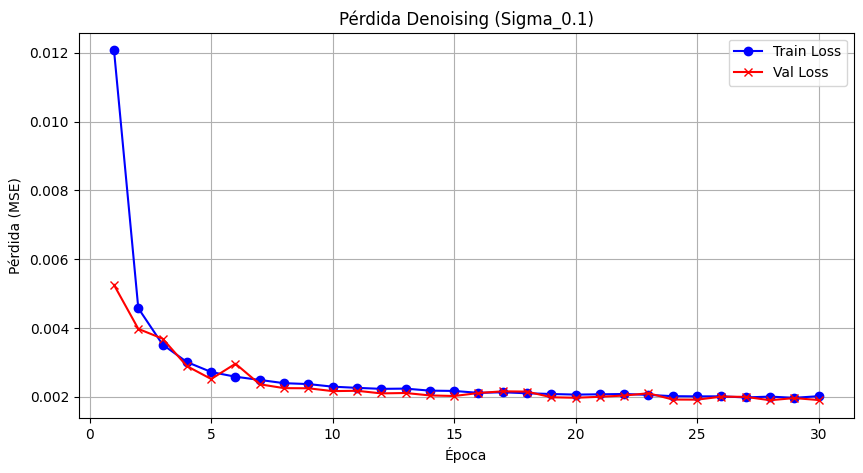

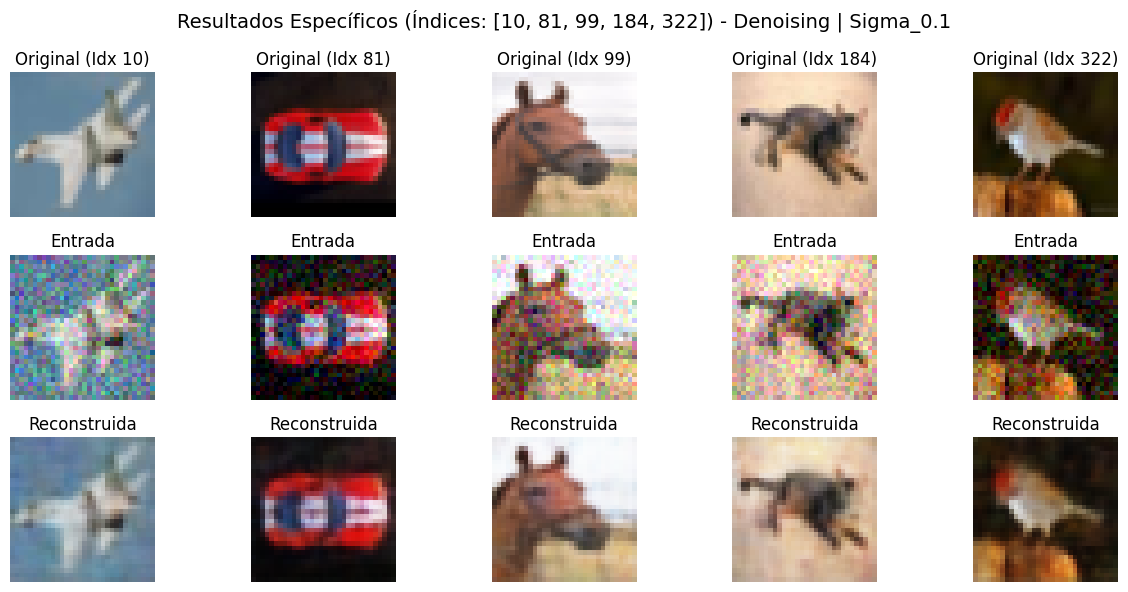


---------------------------------------------
🎯 RESULTADOS FINALES PARA: Sigma_0.1
---------------------------------------------
Train Loss Final : 0.0020
Val Loss Final   : 0.0019
Test Loss Final  : 0.0019
Test PSNR Final  : 27.18 dB
---------------------------------------------


--- Ejecutando Configuración: Sigma_0.3 ---
[Sigma_0.3] Época [1/30] | Train Loss: 0.0155 | Val Loss: 0.0086
[Sigma_0.3] Época [5/30] | Train Loss: 0.0066 | Val Loss: 0.0065
[Sigma_0.3] Época [10/30] | Train Loss: 0.0063 | Val Loss: 0.0063
[Sigma_0.3] Época [15/30] | Train Loss: 0.0062 | Val Loss: 0.0061
[Sigma_0.3] Época [20/30] | Train Loss: 0.0061 | Val Loss: 0.0060
[Sigma_0.3] Época [25/30] | Train Loss: 0.0061 | Val Loss: 0.0059
[Sigma_0.3] Época [30/30] | Train Loss: 0.0060 | Val Loss: 0.0060


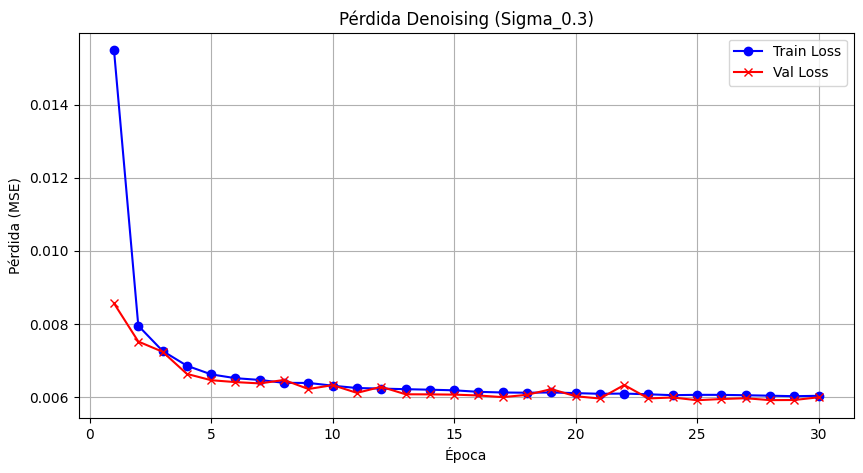

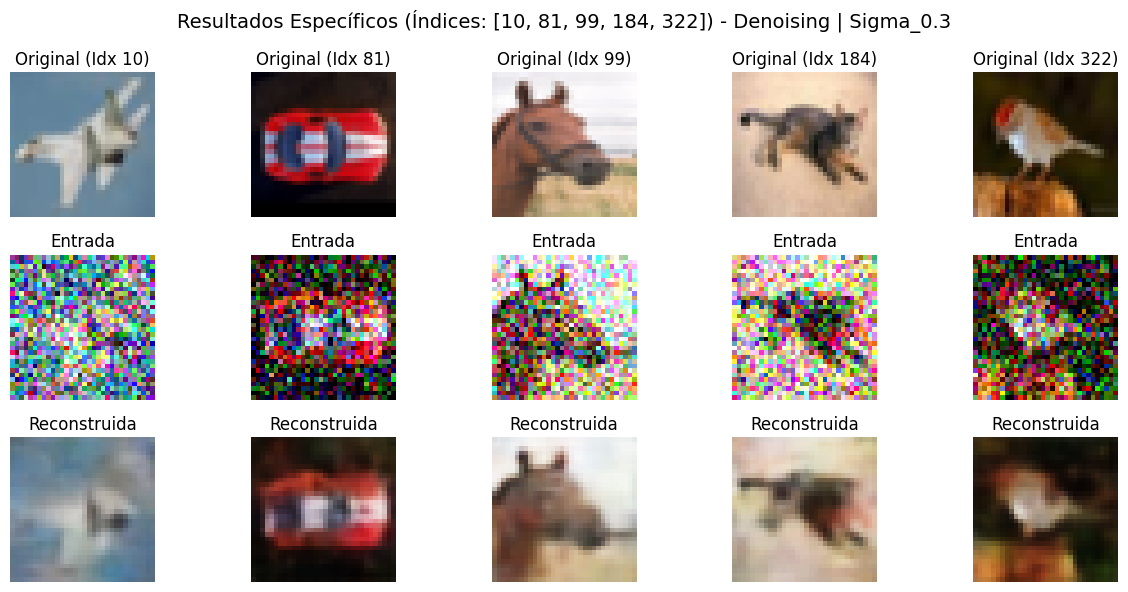


---------------------------------------------
🎯 RESULTADOS FINALES PARA: Sigma_0.3
---------------------------------------------
Train Loss Final : 0.0060
Val Loss Final   : 0.0060
Test Loss Final  : 0.0060
Test PSNR Final  : 22.22 dB
---------------------------------------------


--- Ejecutando Configuración: Sigma_0.5 ---
[Sigma_0.5] Época [1/30] | Train Loss: 0.0184 | Val Loss: 0.0125
[Sigma_0.5] Época [5/30] | Train Loss: 0.0109 | Val Loss: 0.0107
[Sigma_0.5] Época [10/30] | Train Loss: 0.0104 | Val Loss: 0.0103
[Sigma_0.5] Época [15/30] | Train Loss: 0.0103 | Val Loss: 0.0102
[Sigma_0.5] Época [20/30] | Train Loss: 0.0102 | Val Loss: 0.0101
[Sigma_0.5] Época [25/30] | Train Loss: 0.0102 | Val Loss: 0.0100
[Sigma_0.5] Época [30/30] | Train Loss: 0.0101 | Val Loss: 0.0100


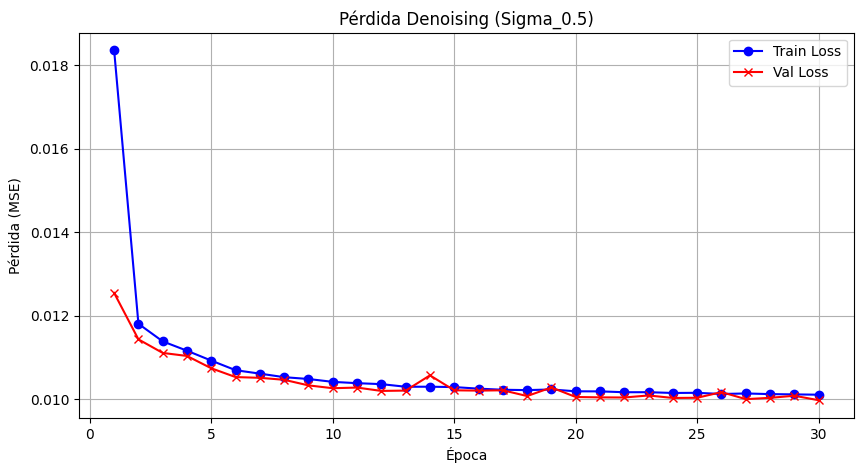

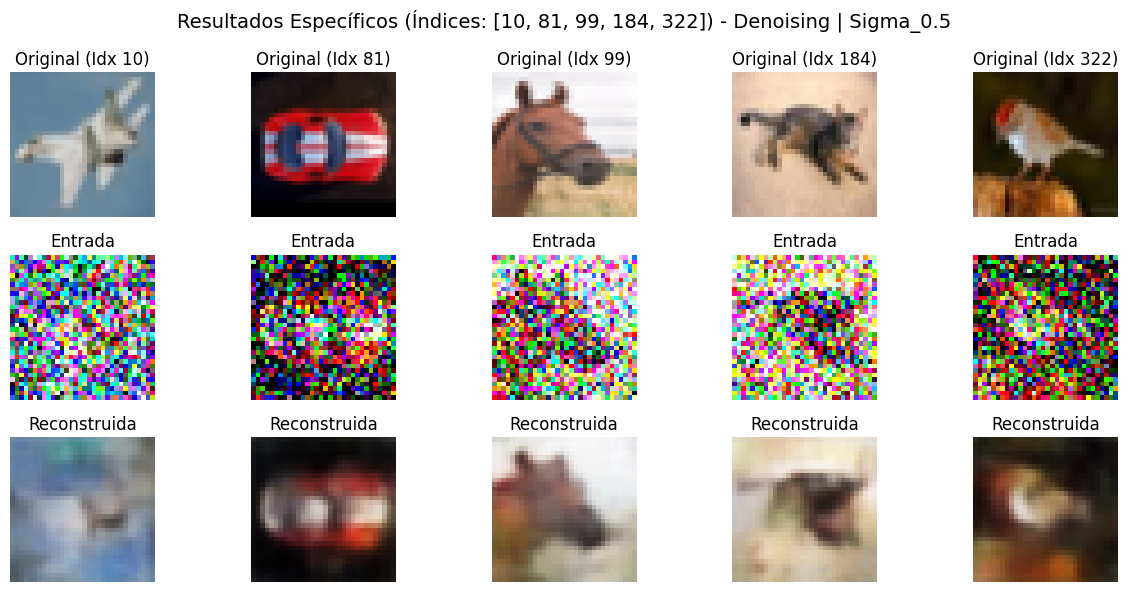


---------------------------------------------
🎯 RESULTADOS FINALES PARA: Sigma_0.5
---------------------------------------------
Train Loss Final : 0.0101
Val Loss Final   : 0.0100
Test Loss Final  : 0.0100
Test PSNR Final  : 19.99 dB
---------------------------------------------



In [ ]:
print("==========================================")
print("INICIANDO EXPERIMENTOS TAREA 1: DENOISING")
print("==========================================")

niveles_sigma = [0.1, 0.3, 0.5]

for s in niveles_sigma:
    exp_name = f"Sigma_{s}"
    print(f"\n--- Ejecutando Configuración: {exp_name} ---")
    
    model_denoising = ConvAutoencoder(in_channels=3, latent_dim=64).to(device)
    
    history = train_and_evaluate(
        model_denoising, 'denoising', train_loader, val_loader, 
        epochs=30, sigma=s, exp_name=exp_name
    )
    
    test_loss, test_psnr = evaluate_on_test(model_denoising, 'denoising', test_loader, sigma=s)
    plot_loss_curves(history, f'Pérdida Denoising ({exp_name})')
    visualize_results(model_denoising, 'denoising', test_loader, indices=mis_fotos, sigma=s, exp_name=exp_name)
    
    print("\n" + "-"*45)
    print(f" RESULTADOS FINALES PARA: {exp_name}")
    print("-"*45)
    print(f"Train Loss Final : {history['train_loss'][-1]:.4f}")
    print(f"Val Loss Final   : {history['val_loss'][-1]:.4f}")
    print(f"Test Loss Final  : {test_loss:.4f}")
    print(f"Test PSNR Final  : {test_psnr:.2f} dB")
    print("-"*45 + "\n")

INICIANDO EXPERIMENTOS TAREA 1: DENOISING (SAL Y PIMIENTA)

--- Ejecutando Configuración: SaltPepper_Prob_0.05 ---
[SaltPepper_Prob_0.05] Época [1/30] | Train Loss: 0.0124 | Val Loss: 0.0060
[SaltPepper_Prob_0.05] Época [5/30] | Train Loss: 0.0023 | Val Loss: 0.0020
[SaltPepper_Prob_0.05] Época [10/30] | Train Loss: 0.0015 | Val Loss: 0.0017
[SaltPepper_Prob_0.05] Época [15/30] | Train Loss: 0.0013 | Val Loss: 0.0012
[SaltPepper_Prob_0.05] Época [20/30] | Train Loss: 0.0011 | Val Loss: 0.0010
[SaltPepper_Prob_0.05] Época [25/30] | Train Loss: 0.0010 | Val Loss: 0.0010
[SaltPepper_Prob_0.05] Época [30/30] | Train Loss: 0.0009 | Val Loss: 0.0009


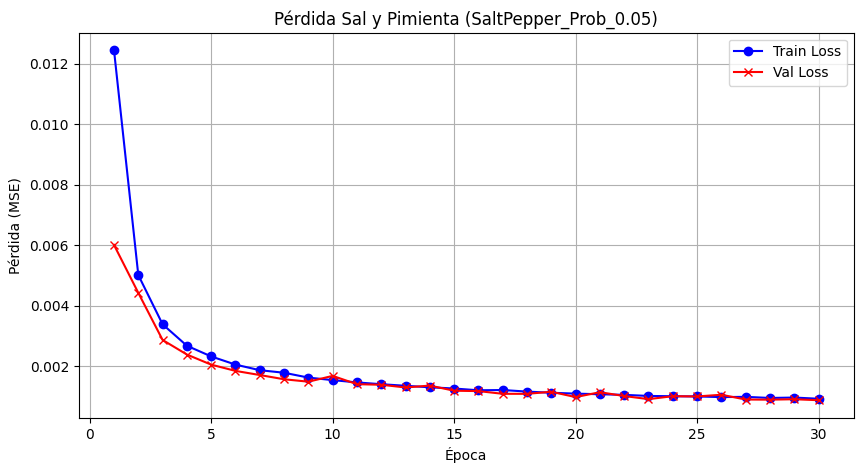

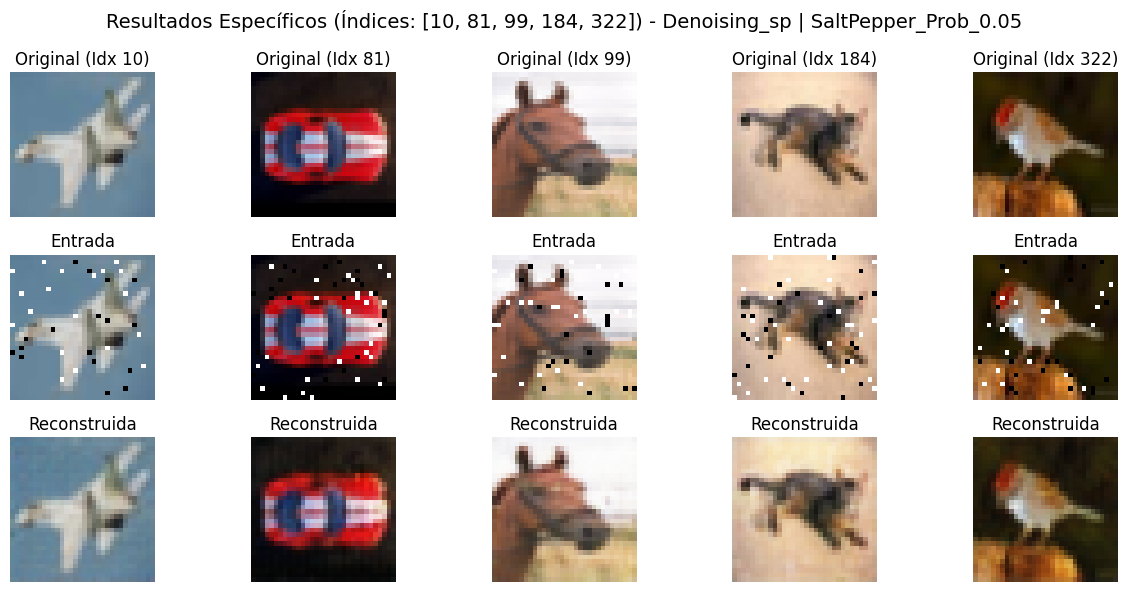


---------------------------------------------
🎯 RESULTADOS FINALES PARA: SaltPepper_Prob_0.05
---------------------------------------------
Train Loss Final : 0.0009
Val Loss Final   : 0.0009
Test Loss Final  : 0.0009
Test PSNR Final  : 30.57 dB
---------------------------------------------


--- Ejecutando Configuración: SaltPepper_Prob_0.1 ---
[SaltPepper_Prob_0.1] Época [1/30] | Train Loss: 0.0168 | Val Loss: 0.0070
[SaltPepper_Prob_0.1] Época [5/30] | Train Loss: 0.0028 | Val Loss: 0.0026
[SaltPepper_Prob_0.1] Época [10/30] | Train Loss: 0.0019 | Val Loss: 0.0017
[SaltPepper_Prob_0.1] Época [15/30] | Train Loss: 0.0016 | Val Loss: 0.0015
[SaltPepper_Prob_0.1] Época [20/30] | Train Loss: 0.0014 | Val Loss: 0.0012
[SaltPepper_Prob_0.1] Época [25/30] | Train Loss: 0.0012 | Val Loss: 0.0011
[SaltPepper_Prob_0.1] Época [30/30] | Train Loss: 0.0011 | Val Loss: 0.0010


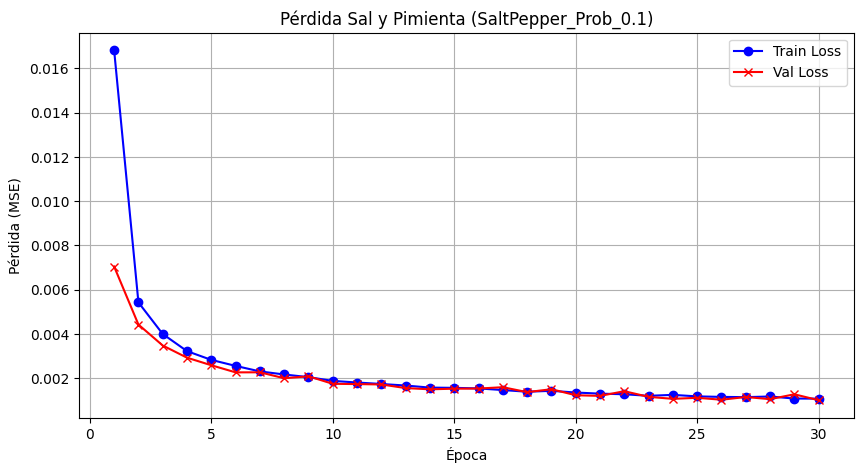

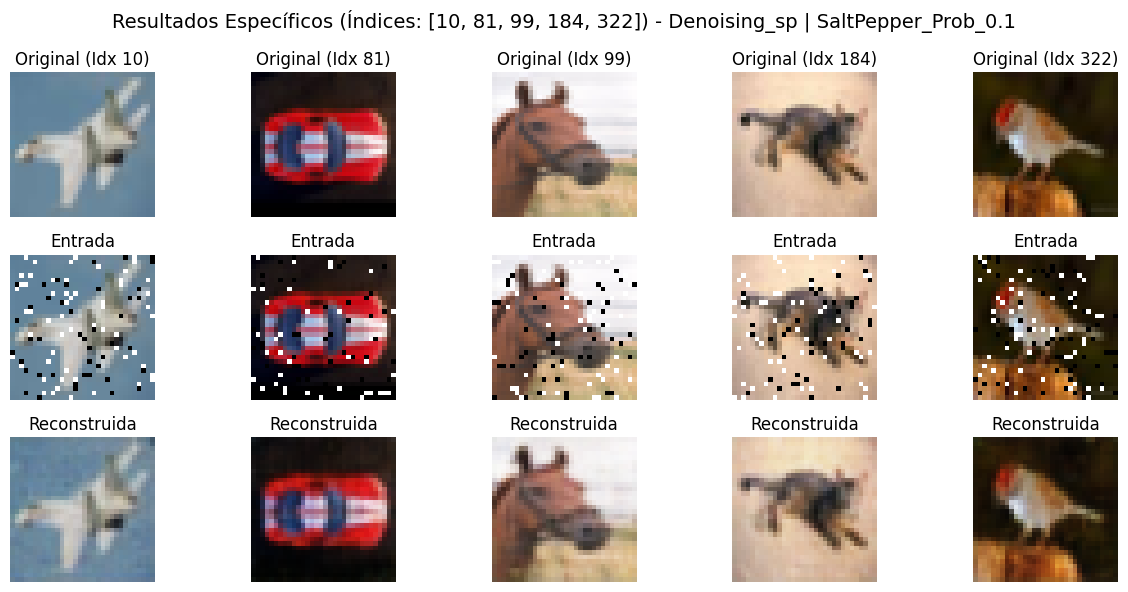


---------------------------------------------
🎯 RESULTADOS FINALES PARA: SaltPepper_Prob_0.1
---------------------------------------------
Train Loss Final : 0.0011
Val Loss Final   : 0.0010
Test Loss Final  : 0.0010
Test PSNR Final  : 29.95 dB
---------------------------------------------


--- Ejecutando Configuración: SaltPepper_Prob_0.2 ---
[SaltPepper_Prob_0.2] Época [1/30] | Train Loss: 0.0163 | Val Loss: 0.0085
[SaltPepper_Prob_0.2] Época [5/30] | Train Loss: 0.0034 | Val Loss: 0.0031
[SaltPepper_Prob_0.2] Época [10/30] | Train Loss: 0.0023 | Val Loss: 0.0023
[SaltPepper_Prob_0.2] Época [15/30] | Train Loss: 0.0019 | Val Loss: 0.0019
[SaltPepper_Prob_0.2] Época [20/30] | Train Loss: 0.0016 | Val Loss: 0.0015
[SaltPepper_Prob_0.2] Época [25/30] | Train Loss: 0.0015 | Val Loss: 0.0015
[SaltPepper_Prob_0.2] Época [30/30] | Train Loss: 0.0013 | Val Loss: 0.0013


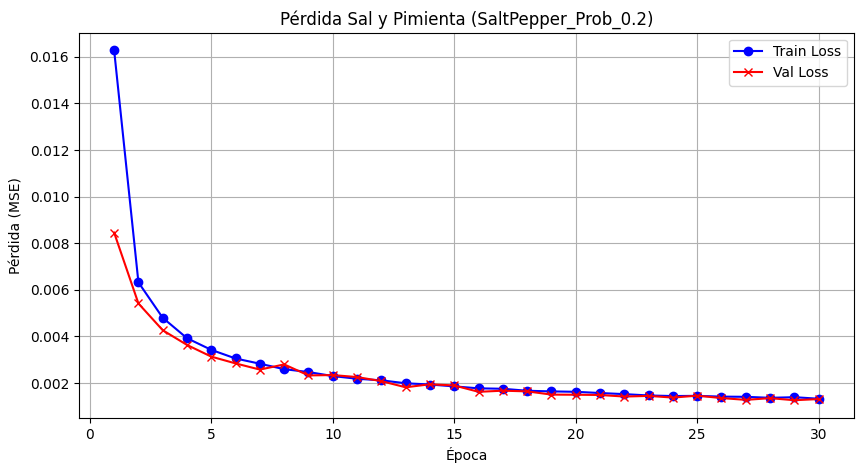

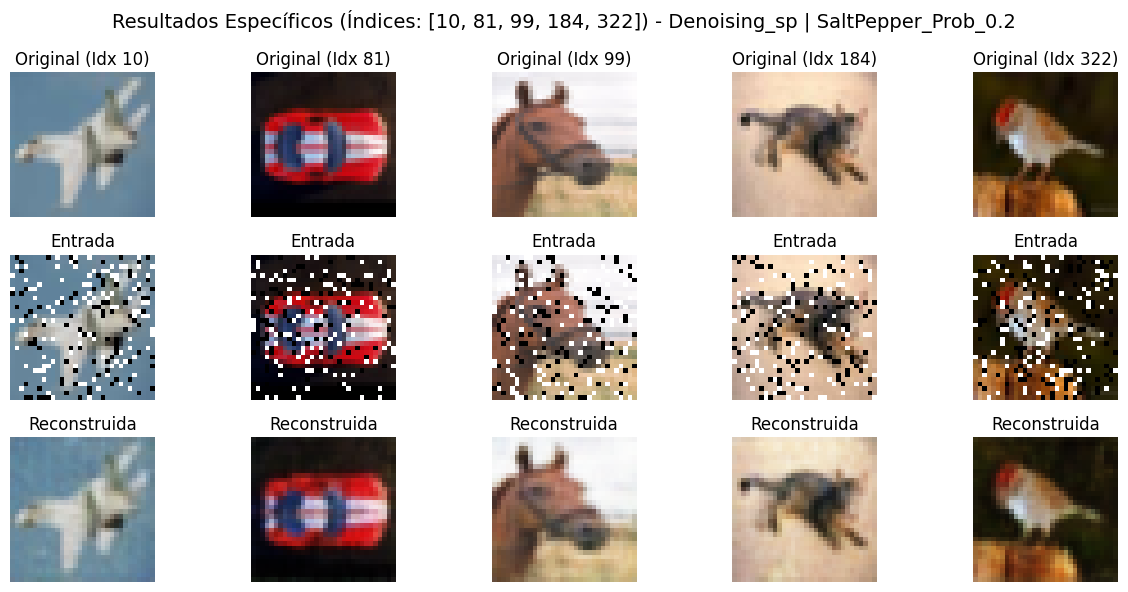


---------------------------------------------
🎯 RESULTADOS FINALES PARA: SaltPepper_Prob_0.2
---------------------------------------------
Train Loss Final : 0.0013
Val Loss Final   : 0.0013
Test Loss Final  : 0.0013
Test PSNR Final  : 28.80 dB
---------------------------------------------



In [ ]:
print("==========================================")
print("INICIANDO EXPERIMENTOS TAREA 1: DENOISING (SAL Y PIMIENTA)")
print("==========================================")

niveles_prob = [0.05, 0.1, 0.2]

for p in niveles_prob:
    exp_name = f"SaltPepper_Prob_{p}"
    print(f"\n--- Ejecutando Configuración: {exp_name} ---")
    
    model_denoising = ConvAutoencoder(in_channels=3, latent_dim=64).to(device)
    
    history = train_and_evaluate(
        model_denoising, 'denoising_sp', train_loader, val_loader, 
        epochs=30, prob=p, exp_name=exp_name
    )
    
    test_loss, test_psnr = evaluate_on_test(model_denoising, 'denoising_sp', test_loader, prob=p)
    plot_loss_curves(history, f'Pérdida Sal y Pimienta ({exp_name})')
    visualize_results(model_denoising, 'denoising_sp', test_loader, indices=mis_fotos, prob=p, exp_name=exp_name)
    
    print("\n" + "-"*45)
    print(f"🎯 RESULTADOS FINALES PARA: {exp_name}")
    print("-"*45)
    print(f"Train Loss Final : {history['train_loss'][-1]:.4f}")
    print(f"Val Loss Final   : {history['val_loss'][-1]:.4f}")
    print(f"Test Loss Final  : {test_loss:.4f}")
    print(f"Test PSNR Final  : {test_psnr:.2f} dB")
    print("-"*45 + "\n")

INICIANDO EXPERIMENTOS TAREA 2: COLORIZATION

--- Ejecutando Configuración: Latent_Dim_16 ---
[Latent_Dim_16] Época [1/30] | Train Loss: 0.0177 | Val Loss: 0.0103
[Latent_Dim_16] Época [5/30] | Train Loss: 0.0076 | Val Loss: 0.0079
[Latent_Dim_16] Época [10/30] | Train Loss: 0.0066 | Val Loss: 0.0067
[Latent_Dim_16] Época [15/30] | Train Loss: 0.0062 | Val Loss: 0.0064
[Latent_Dim_16] Época [20/30] | Train Loss: 0.0061 | Val Loss: 0.0061
[Latent_Dim_16] Época [25/30] | Train Loss: 0.0060 | Val Loss: 0.0067
[Latent_Dim_16] Época [30/30] | Train Loss: 0.0059 | Val Loss: 0.0060


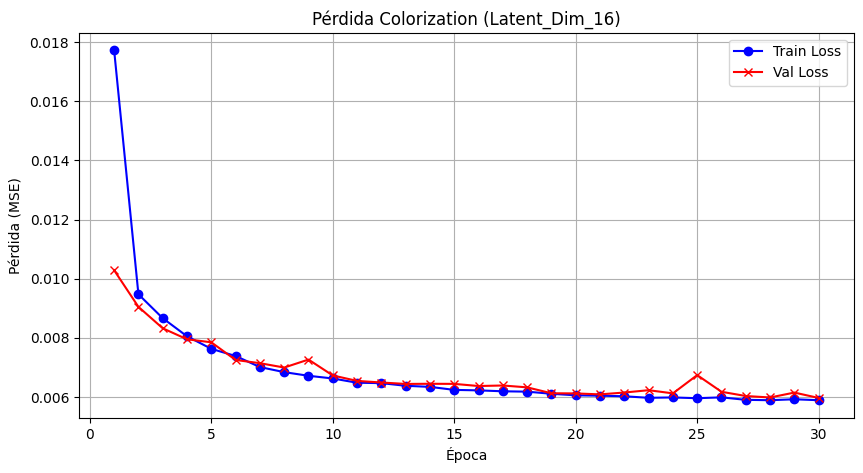

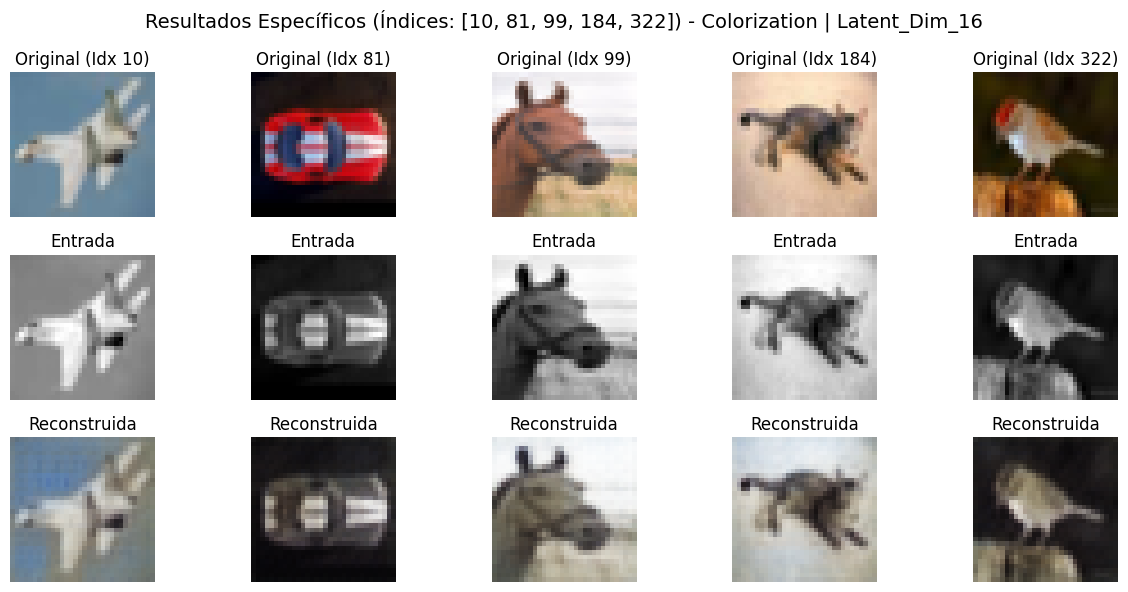


---------------------------------------------
RESULTADOS FINALES PARA: Latent_Dim_16
---------------------------------------------
Train Loss Final : 0.0059
Val Loss Final   : 0.0060
Test Loss Final  : 0.0058
Test PSNR Final  : 22.39 dB
---------------------------------------------


--- Ejecutando Configuración: Latent_Dim_64 ---
[Latent_Dim_64] Época [1/30] | Train Loss: 0.0141 | Val Loss: 0.0093
[Latent_Dim_64] Época [5/30] | Train Loss: 0.0065 | Val Loss: 0.0065
[Latent_Dim_64] Época [10/30] | Train Loss: 0.0060 | Val Loss: 0.0062
[Latent_Dim_64] Época [15/30] | Train Loss: 0.0058 | Val Loss: 0.0059
[Latent_Dim_64] Época [20/30] | Train Loss: 0.0057 | Val Loss: 0.0058
[Latent_Dim_64] Época [25/30] | Train Loss: 0.0056 | Val Loss: 0.0057
[Latent_Dim_64] Época [30/30] | Train Loss: 0.0056 | Val Loss: 0.0058


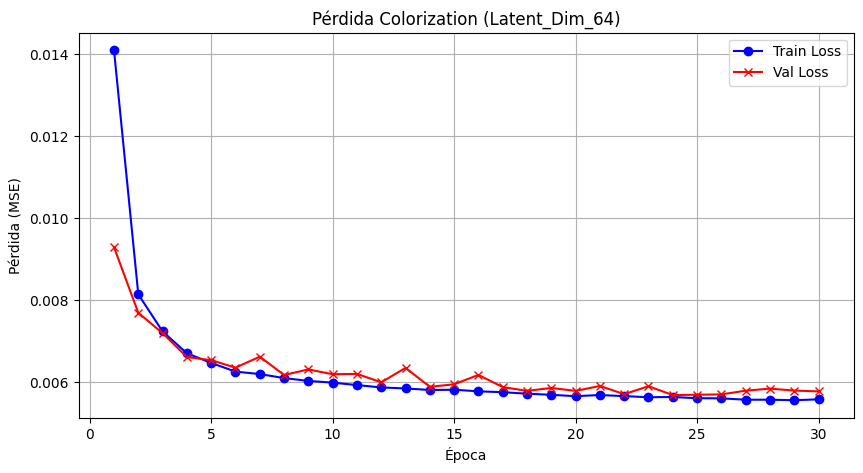

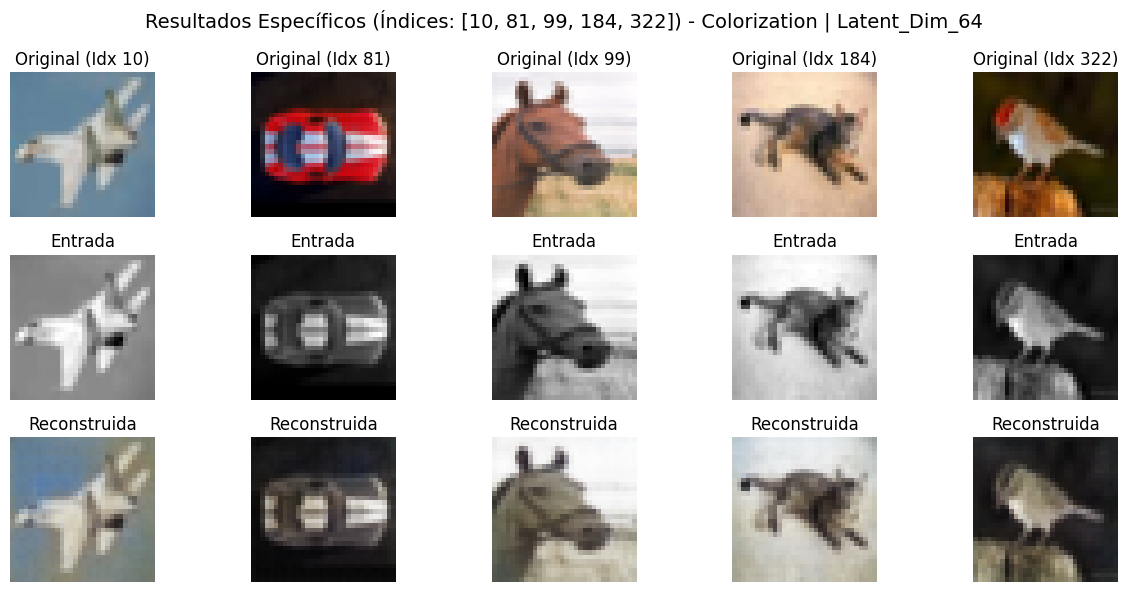


---------------------------------------------
RESULTADOS FINALES PARA: Latent_Dim_64
---------------------------------------------
Train Loss Final : 0.0056
Val Loss Final   : 0.0058
Test Loss Final  : 0.0056
Test PSNR Final  : 22.54 dB
---------------------------------------------


--- Ejecutando Configuración: Latent_Dim_256 ---
[Latent_Dim_256] Época [1/30] | Train Loss: 0.0126 | Val Loss: 0.0080
[Latent_Dim_256] Época [5/30] | Train Loss: 0.0062 | Val Loss: 0.0064
[Latent_Dim_256] Época [10/30] | Train Loss: 0.0058 | Val Loss: 0.0059
[Latent_Dim_256] Época [15/30] | Train Loss: 0.0056 | Val Loss: 0.0058
[Latent_Dim_256] Época [20/30] | Train Loss: 0.0056 | Val Loss: 0.0057
[Latent_Dim_256] Época [25/30] | Train Loss: 0.0055 | Val Loss: 0.0056
[Latent_Dim_256] Época [30/30] | Train Loss: 0.0055 | Val Loss: 0.0056


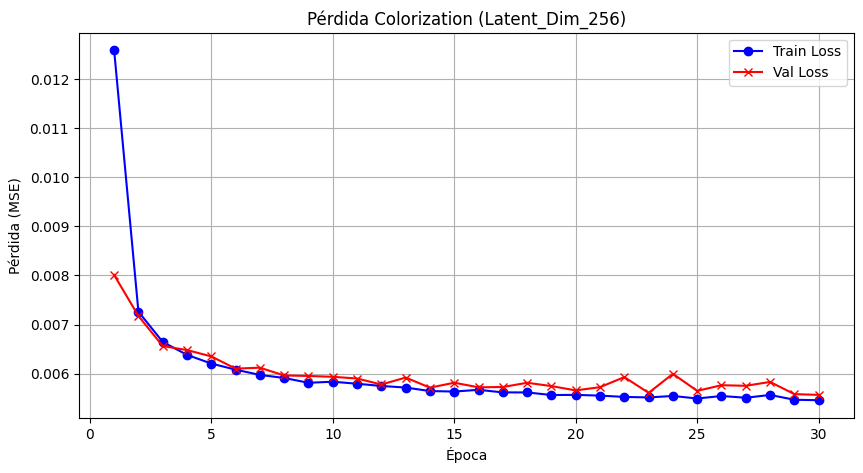

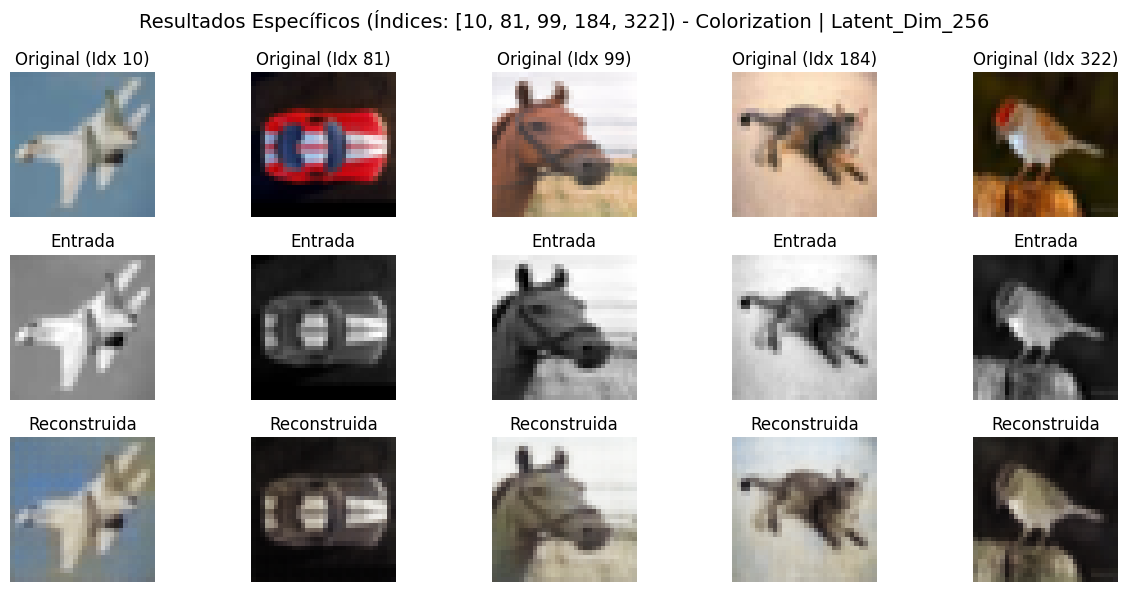


---------------------------------------------
RESULTADOS FINALES PARA: Latent_Dim_256
---------------------------------------------
Train Loss Final : 0.0055
Val Loss Final   : 0.0056
Test Loss Final  : 0.0054
Test PSNR Final  : 22.70 dB
---------------------------------------------



In [ ]:
print("==========================================")
print("INICIANDO EXPERIMENTOS TAREA 2: COLORIZATION")
print("==========================================")

dimensiones_latentes = [16, 64, 256]

for ld in dimensiones_latentes:
    exp_name = f"Latent_Dim_{ld}"
    print(f"\n--- Ejecutando Configuración: {exp_name} ---")
    
    model_colorization = ConvAutoencoder(in_channels=1, latent_dim=ld).to(device)
    
    history = train_and_evaluate(
        model_colorization, 'colorization', train_loader, val_loader, 
        epochs=30, exp_name=exp_name
    )

    test_loss, test_psnr = evaluate_on_test(model_colorization, 'colorization', test_loader)
    plot_loss_curves(history, f'Pérdida Colorization ({exp_name})')
    visualize_results(model_colorization, 'colorization', test_loader, indices=mis_fotos, exp_name=exp_name)

    print("\n" + "-"*45)
    print(f"RESULTADOS FINALES PARA: {exp_name}")
    print("-"*45)
    print(f"Train Loss Final : {history['train_loss'][-1]:.4f}")
    print(f"Val Loss Final   : {history['val_loss'][-1]:.4f}")
    print(f"Test Loss Final  : {test_loss:.4f}")
    print(f"Test PSNR Final  : {test_psnr:.2f} dB") # Opcional: mostrar la calidad
    print("-"*45 + "\n")

INICIANDO EXPERIMENTOS TAREA 3: INPAINTING

--- Ejecutando Configuración: Mask_8x8 ---
[Mask_8x8] Época [1/30] | Train Loss: 0.0143 | Val Loss: 0.0062
[Mask_8x8] Época [5/30] | Train Loss: 0.0034 | Val Loss: 0.0032
[Mask_8x8] Época [10/30] | Train Loss: 0.0026 | Val Loss: 0.0027
[Mask_8x8] Época [15/30] | Train Loss: 0.0023 | Val Loss: 0.0022
[Mask_8x8] Época [20/30] | Train Loss: 0.0020 | Val Loss: 0.0020
[Mask_8x8] Época [25/30] | Train Loss: 0.0018 | Val Loss: 0.0018
[Mask_8x8] Época [30/30] | Train Loss: 0.0018 | Val Loss: 0.0018


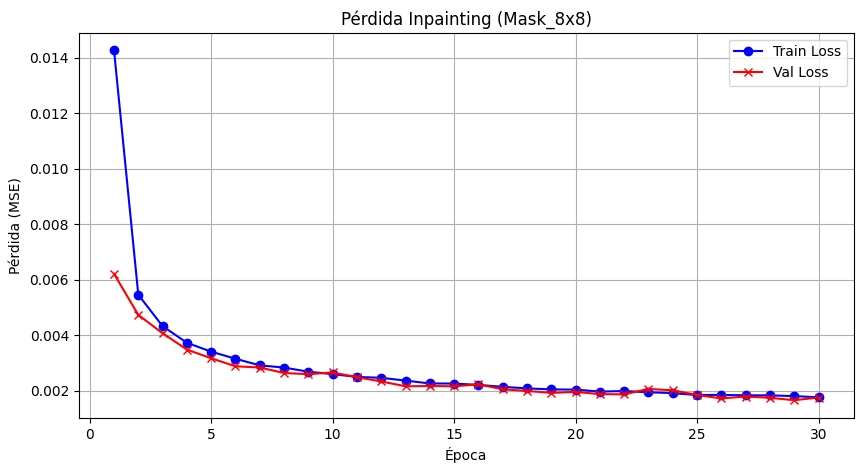

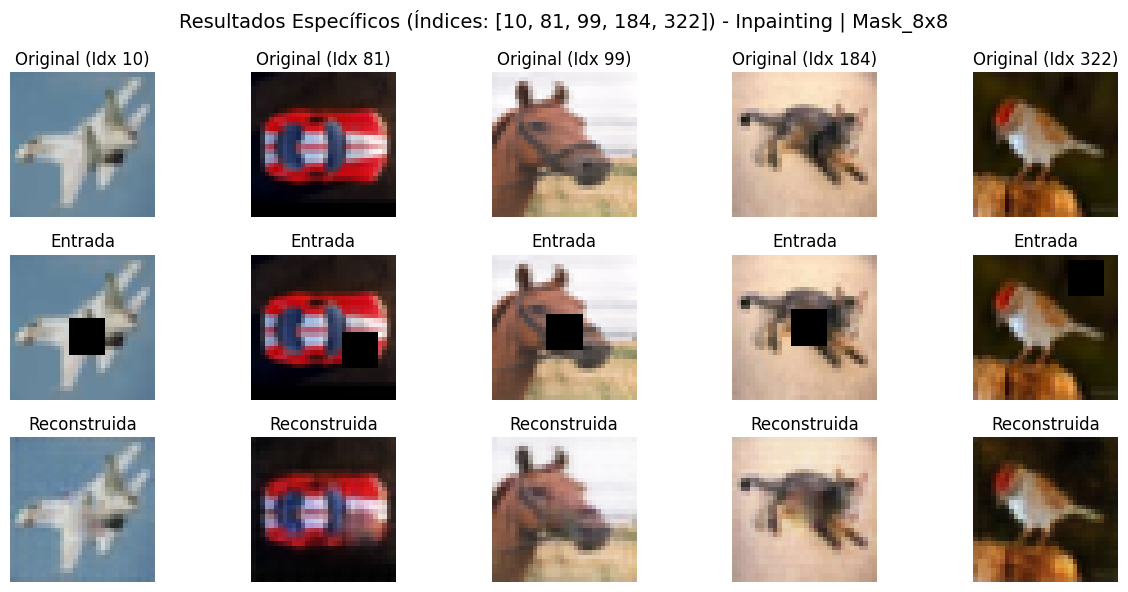


---------------------------------------------
🎯 RESULTADOS FINALES PARA: Mask_8x8
---------------------------------------------
Train Loss Final : 0.0018
Val Loss Final   : 0.0018
Test Loss Final  : 0.0018
Test PSNR Final  : 27.46 dB
---------------------------------------------


--- Ejecutando Configuración: Mask_16x16 ---
[Mask_16x16] Época [1/30] | Train Loss: 0.0207 | Val Loss: 0.0128
[Mask_16x16] Época [5/30] | Train Loss: 0.0099 | Val Loss: 0.0103
[Mask_16x16] Época [10/30] | Train Loss: 0.0088 | Val Loss: 0.0088
[Mask_16x16] Época [15/30] | Train Loss: 0.0085 | Val Loss: 0.0086
[Mask_16x16] Época [20/30] | Train Loss: 0.0083 | Val Loss: 0.0082
[Mask_16x16] Época [25/30] | Train Loss: 0.0081 | Val Loss: 0.0081
[Mask_16x16] Época [30/30] | Train Loss: 0.0080 | Val Loss: 0.0080


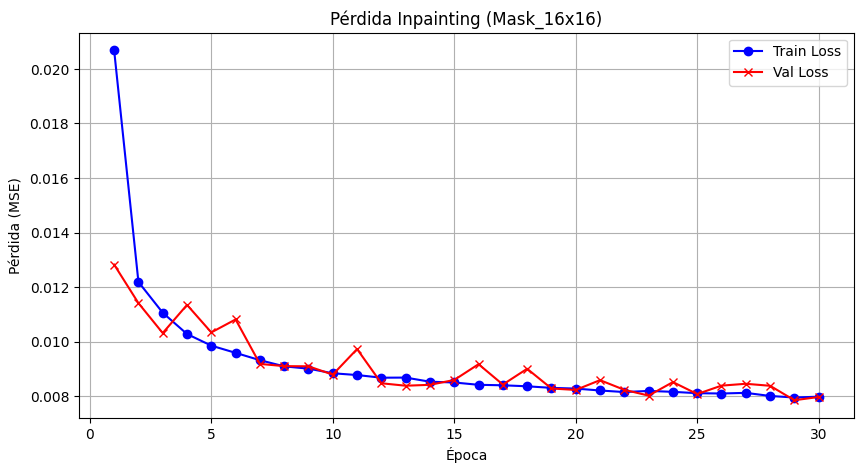

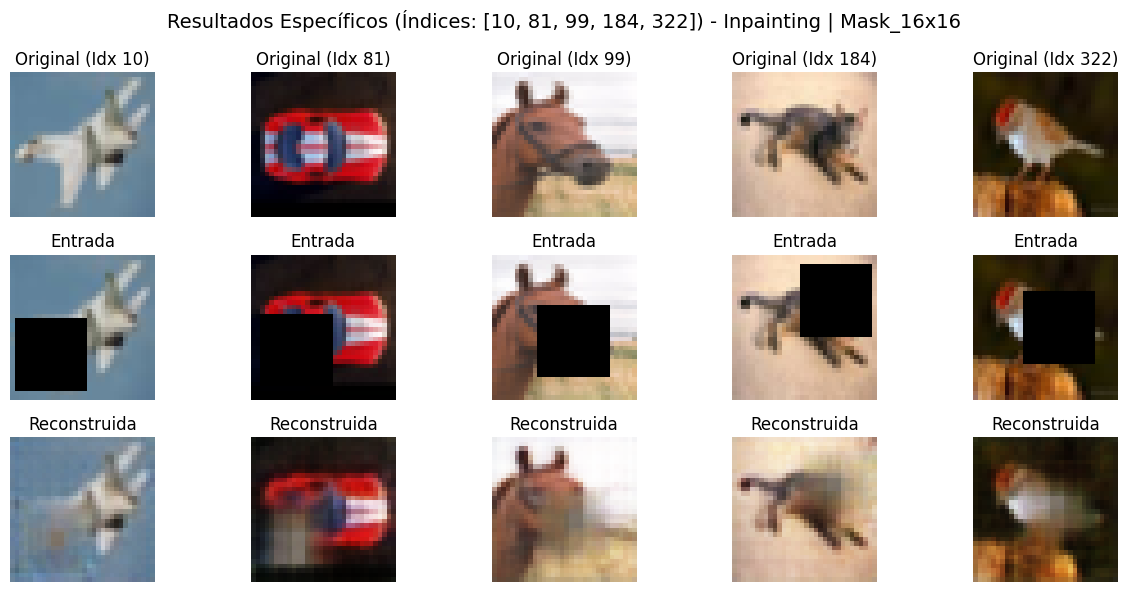


---------------------------------------------
🎯 RESULTADOS FINALES PARA: Mask_16x16
---------------------------------------------
Train Loss Final : 0.0080
Val Loss Final   : 0.0080
Test Loss Final  : 0.0081
Test PSNR Final  : 20.90 dB
---------------------------------------------


--- Ejecutando Configuración: Mask_20x20 ---
[Mask_20x20] Época [1/30] | Train Loss: 0.0245 | Val Loss: 0.0181
[Mask_20x20] Época [5/30] | Train Loss: 0.0152 | Val Loss: 0.0153
[Mask_20x20] Época [10/30] | Train Loss: 0.0142 | Val Loss: 0.0142
[Mask_20x20] Época [15/30] | Train Loss: 0.0139 | Val Loss: 0.0157
[Mask_20x20] Época [20/30] | Train Loss: 0.0137 | Val Loss: 0.0139
[Mask_20x20] Época [25/30] | Train Loss: 0.0136 | Val Loss: 0.0136
[Mask_20x20] Época [30/30] | Train Loss: 0.0134 | Val Loss: 0.0166


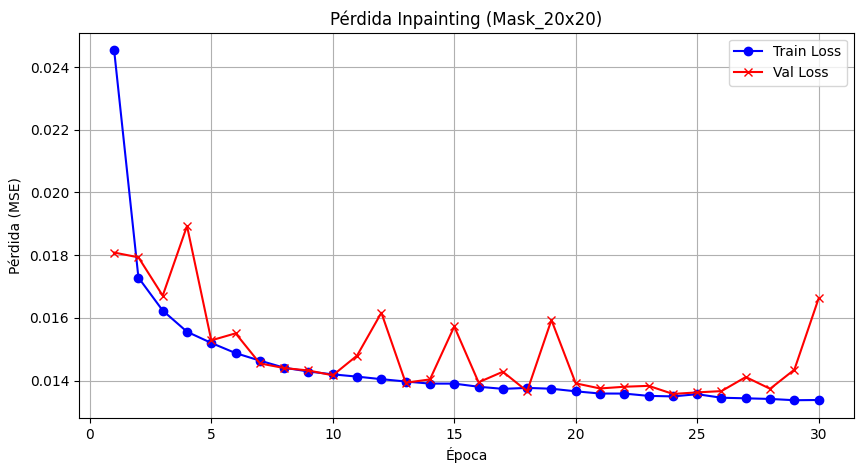

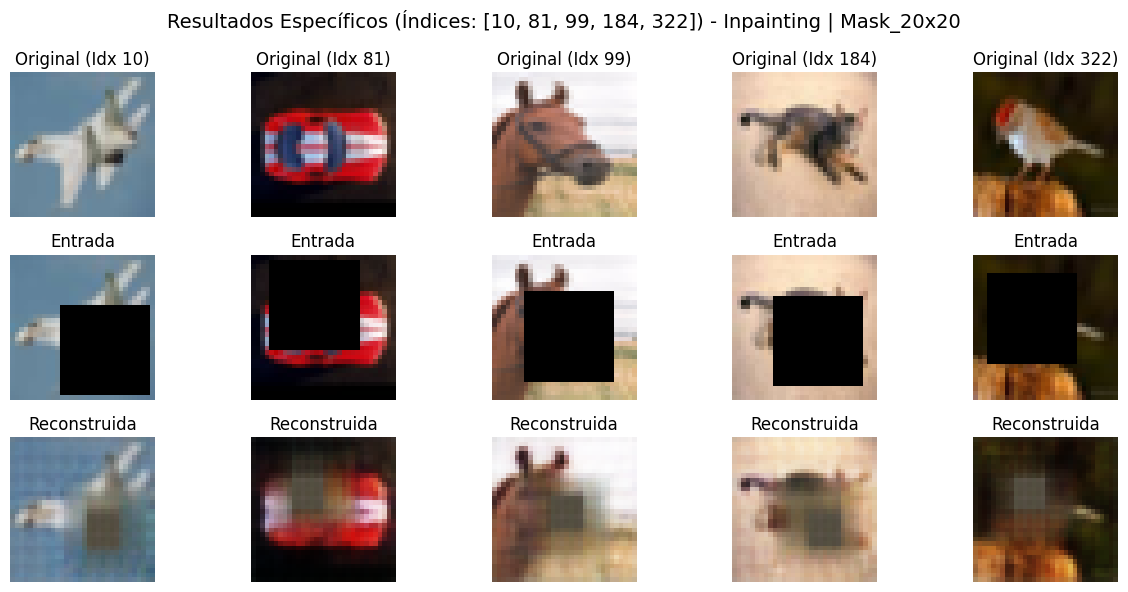


---------------------------------------------
🎯 RESULTADOS FINALES PARA: Mask_20x20
---------------------------------------------
Train Loss Final : 0.0134
Val Loss Final   : 0.0166
Test Loss Final  : 0.0167
Test PSNR Final  : 17.77 dB
---------------------------------------------



In [ ]:
print("==========================================")
print("INICIANDO EXPERIMENTOS TAREA 3: INPAINTING")
print("==========================================")

tamanos_mascara = [8, 16, 20]

for mask_sz in tamanos_mascara:
    exp_name = f"Mask_{mask_sz}x{mask_sz}"
    print(f"\n--- Ejecutando Configuración: {exp_name} ---")
    
    model_inpainting = ConvAutoencoder(in_channels=3, latent_dim=64).to(device)
    
    history = train_and_evaluate(
        model_inpainting, 'inpainting', train_loader, val_loader, 
        epochs=30, mask_size=mask_sz, exp_name=exp_name
    )
    
    test_loss, test_psnr = evaluate_on_test(model_inpainting, 'inpainting', test_loader, mask_size=mask_sz)
    plot_loss_curves(history, f'Pérdida Inpainting ({exp_name})')
    visualize_results(model_inpainting, 'inpainting', test_loader, indices=mis_fotos, mask_size=mask_sz, exp_name=exp_name)
    
    print("\n" + "-"*45)
    print(f" RESULTADOS FINALES PARA: {exp_name}")
    print("-"*45)
    print(f"Train Loss Final : {history['train_loss'][-1]:.4f}")
    print(f"Val Loss Final   : {history['val_loss'][-1]:.4f}")
    print(f"Test Loss Final  : {test_loss:.4f}")
    print(f"Test PSNR Final  : {test_psnr:.2f} dB")
    print("-"*45 + "\n")

INICIANDO EXPERIMENTOS TAREA 2: COLORIZATION

--- Ejecutando Configuración: Latent_Dim_16 ---
[Latent_Dim_16] Época [1/30] | Train Loss: 0.0135 | Val Loss: 0.0089
[Latent_Dim_16] Época [5/30] | Train Loss: 0.0066 | Val Loss: 0.0070
[Latent_Dim_16] Época [10/30] | Train Loss: 0.0059 | Val Loss: 0.0058
[Latent_Dim_16] Época [15/30] | Train Loss: 0.0057 | Val Loss: 0.0060
[Latent_Dim_16] Época [20/30] | Train Loss: 0.0055 | Val Loss: 0.0066
[Latent_Dim_16] Época [25/30] | Train Loss: 0.0054 | Val Loss: 0.0058
[Latent_Dim_16] Época [30/30] | Train Loss: 0.0053 | Val Loss: 0.0054


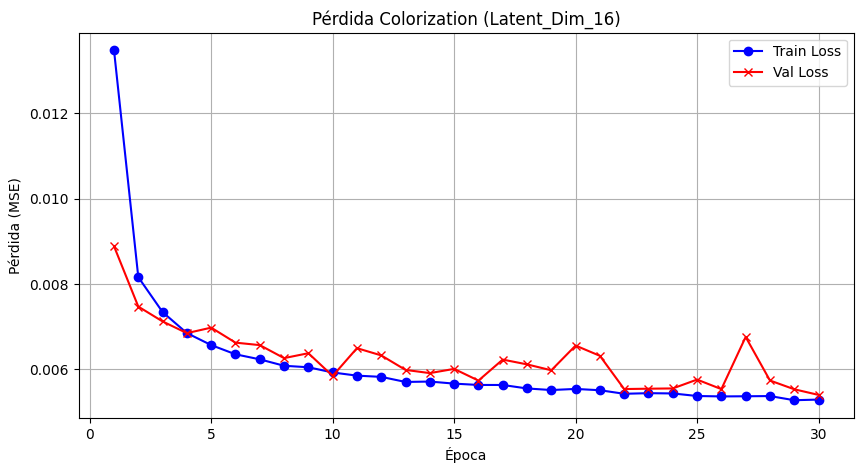

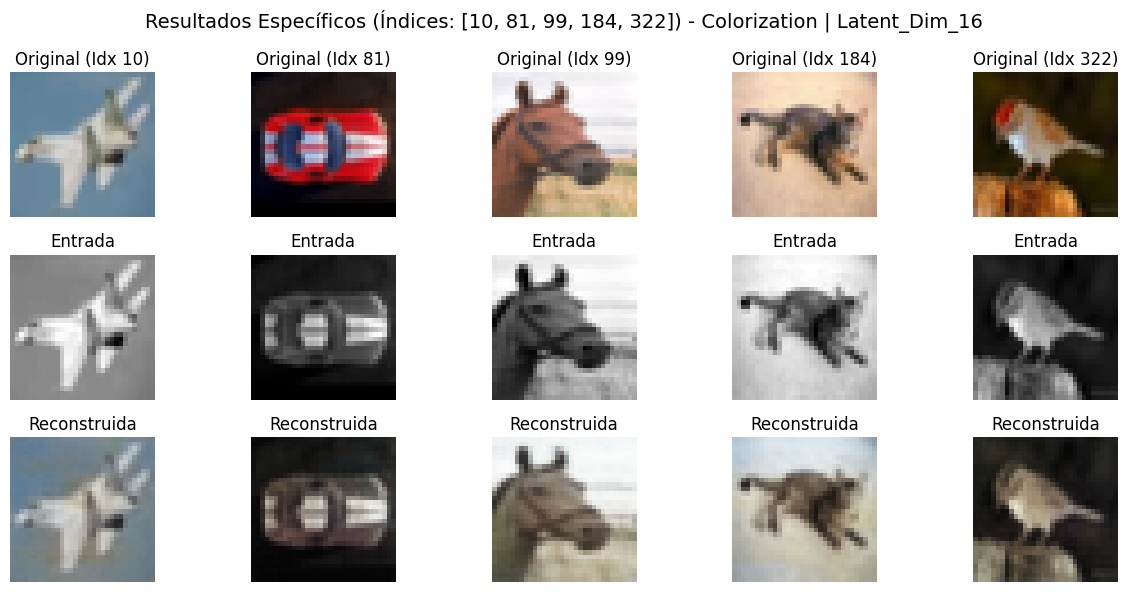


---------------------------------------------
RESULTADOS FINALES PARA: Latent_Dim_16
---------------------------------------------
Train Loss Final : 0.0053
Val Loss Final   : 0.0054
Test Loss Final  : 0.0053
Test PSNR Final  : 22.76 dB
---------------------------------------------


--- Ejecutando Configuración: Latent_Dim_64 ---
[Latent_Dim_64] Época [1/30] | Train Loss: 0.0128 | Val Loss: 0.0086
[Latent_Dim_64] Época [5/30] | Train Loss: 0.0062 | Val Loss: 0.0062
[Latent_Dim_64] Época [10/30] | Train Loss: 0.0056 | Val Loss: 0.0056
[Latent_Dim_64] Época [15/30] | Train Loss: 0.0054 | Val Loss: 0.0055
[Latent_Dim_64] Época [20/30] | Train Loss: 0.0053 | Val Loss: 0.0054
[Latent_Dim_64] Época [25/30] | Train Loss: 0.0051 | Val Loss: 0.0054
[Latent_Dim_64] Época [30/30] | Train Loss: 0.0050 | Val Loss: 0.0059


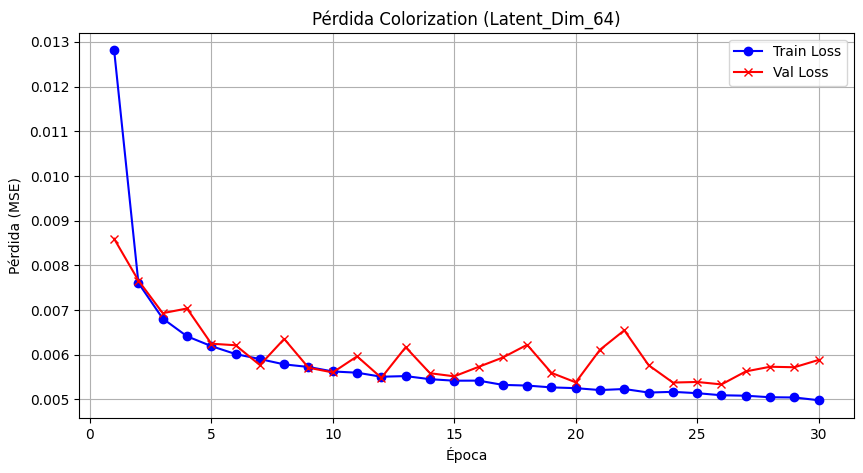

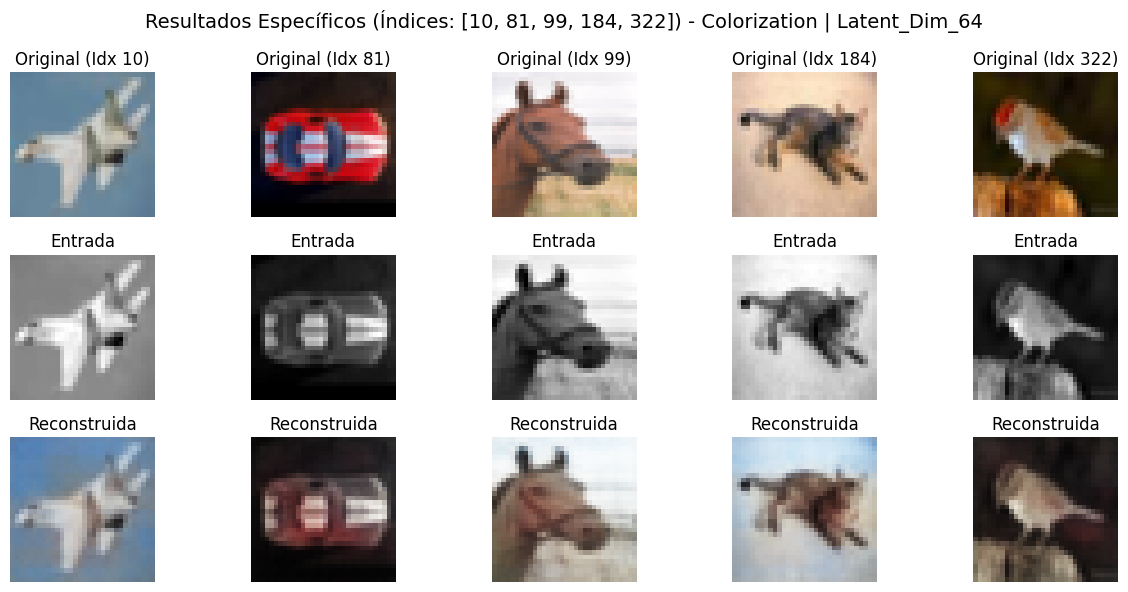


---------------------------------------------
RESULTADOS FINALES PARA: Latent_Dim_64
---------------------------------------------
Train Loss Final : 0.0050
Val Loss Final   : 0.0059
Test Loss Final  : 0.0058
Test PSNR Final  : 22.39 dB
---------------------------------------------


--- Ejecutando Configuración: Latent_Dim_256 ---
[Latent_Dim_256] Época [1/30] | Train Loss: 0.0112 | Val Loss: 0.0084
[Latent_Dim_256] Época [5/30] | Train Loss: 0.0059 | Val Loss: 0.0068
[Latent_Dim_256] Época [10/30] | Train Loss: 0.0055 | Val Loss: 0.0057
[Latent_Dim_256] Época [15/30] | Train Loss: 0.0052 | Val Loss: 0.0059
[Latent_Dim_256] Época [20/30] | Train Loss: 0.0050 | Val Loss: 0.0060
[Latent_Dim_256] Época [25/30] | Train Loss: 0.0047 | Val Loss: 0.0056
[Latent_Dim_256] Época [30/30] | Train Loss: 0.0044 | Val Loss: 0.0067


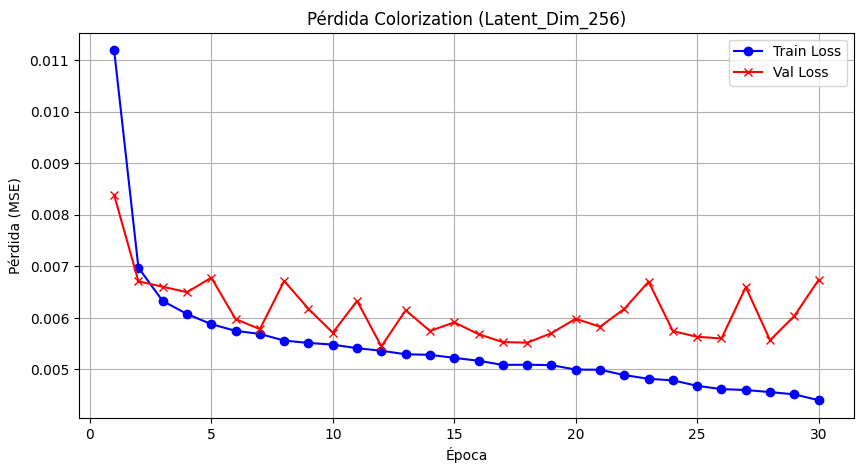

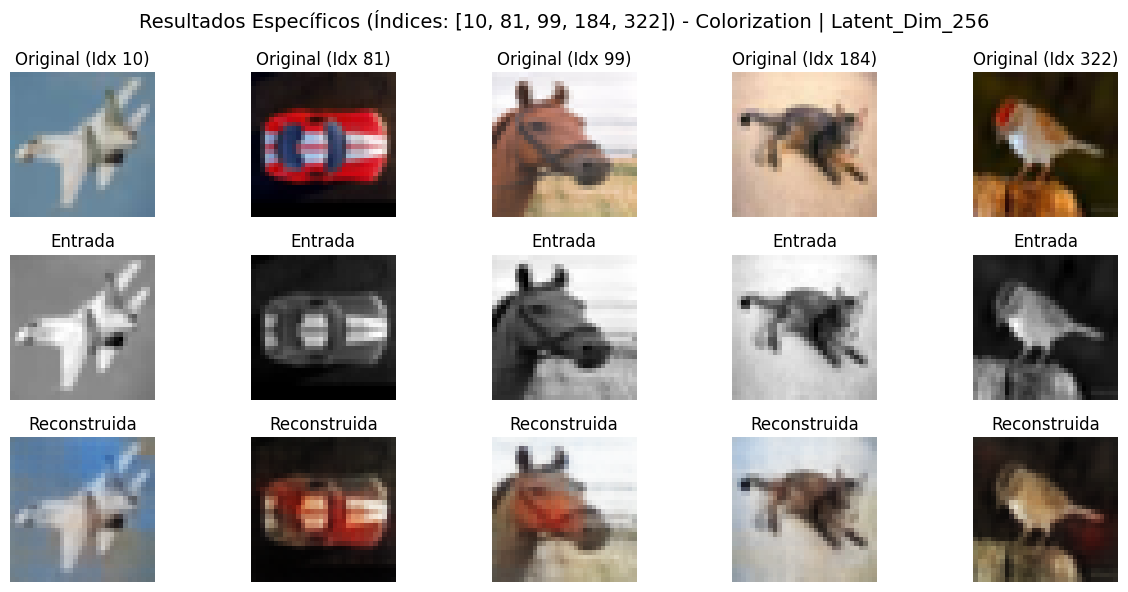


---------------------------------------------
RESULTADOS FINALES PARA: Latent_Dim_256
---------------------------------------------
Train Loss Final : 0.0044
Val Loss Final   : 0.0067
Test Loss Final  : 0.0066
Test PSNR Final  : 21.80 dB
---------------------------------------------



In [ ]:
print("==========================================")
print("INICIANDO EXPERIMENTOS TAREA 2: COLORIZATION")
print("==========================================")

dimensiones_latentes = [16, 64, 256]

for ld in dimensiones_latentes:
    exp_name = f"Latent_Dim_{ld}"
    print(f"\n--- Ejecutando Configuración: {exp_name} ---")
    
    model_colorization = ConvAutoencoder(in_channels=1, latent_dim=ld).to(device)

    history = train_and_evaluate(
        model_colorization, 'colorization', train_loader, val_loader, 
        epochs=30, exp_name=exp_name
    )

    test_loss, test_psnr = evaluate_on_test(model_colorization, 'colorization', test_loader)
    
    plot_loss_curves(history, f'Pérdida Colorization ({exp_name})')
    visualize_results(model_colorization, 'colorization', test_loader, indices=mis_fotos, exp_name=exp_name)

    
    print("\n" + "-"*45)
    print(f"RESULTADOS FINALES PARA: {exp_name}")
    print("-"*45)
    print(f"Train Loss Final : {history['train_loss'][-1]:.4f}")
    print(f"Val Loss Final   : {history['val_loss'][-1]:.4f}")
    print(f"Test Loss Final  : {test_loss:.4f}")
    print(f"Test PSNR Final  : {test_psnr:.2f} dB") # Opcional: mostrar la calidad
    print("-"*45 + "\n")